<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
unit: Unit 2 — Machine Learning Techniques
submodule: 2.2 Unsupervised Learning — Dimensionality Reduction & Clustering
document_type: Practical Laboratory Notebook
ai_tier: Full AI (Learning Aid)
---

# 🔍 Hands-On: Unsupervised Learning — Dimensionality Reduction & Clustering

In supervised learning, we always have target labels (such as *Malignant vs. Benign*). In **Unsupervised Learning**, we have **no target labels** — we are given only the input features.

In this notebook, we practice the core concepts from the theory primer:
1. **Dimensionality Reduction:**
   * **PCA (Linear):** Compressing 30 measurements into 2 summary axes (PC1 & PC2).
   * **Scree Plot:** Using the elbow method to decide how many components to keep.
   * **t-SNE (Non-Linear):** Unrolling complex data into separated islands on a 2D map.
2. **Clustering:**
   * **K-Means:** Grouping patients into clusters and using Elbow and Silhouette plots to pick $K$.
   * **Hierarchical Clustering:** Building a dendrogram tree and cutting it to reveal patient groups.
   * **Clustermap:** Grouping patients and co-regulated genes at the same time.
3. **The Standard Workflow:** Combining PCA + K-Means together for clean, noise-free biological clustering.

## Step 0: Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# Simple clean plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
RANDOM_STATE = 42

print("✓ Core libraries imported successfully.")

✓ Core libraries imported successfully.


---
## Part 1: Dimensionality Reduction

Imagine we have biopsy data from **569 patients**, and for every patient, **30 different cell measurements** were taken (cell size, texture, perimeter, smoothness, etc.).

Looking at 30 numbers at the same time is impossible for human eyes. We need **dimensionality reduction** to compress these 30 measurements into 2 or 3 summary numbers that we can easily plot and explore.

### Step 1: Why We Must Standardize First

Let's look at the numbers. In biological data, different measurements use completely different scales:
* `mean area` has values in the **hundreds or thousands** (~650 to 2500).
* `mean fractal dimension` has tiny values around **0.06**.

If we don't scale the data, `mean area` will completely dominate the analysis simply because its numbers are bigger!

In [2]:
# 1. Load the breast cancer dataset
cancer = load_breast_cancer(as_frame=True)
X_raw = cancer.data
feature_names = cancer.feature_names

print(f"Dataset shape: {X_raw.shape[0]} patients x {X_raw.shape[1]} measurements")
print("\nNotice the huge difference in scale:")
print(f"mean area:              min = {X_raw['mean area'].min():.1f}, max = {X_raw['mean area'].max():.1f}")
print(f"mean fractal dimension: min = {X_raw['mean fractal dimension'].min():.3f}, max = {X_raw['mean fractal dimension'].max():.3f}")

Dataset shape: 569 patients x 30 measurements

Notice the huge difference in scale:
mean area:              min = 143.5, max = 2501.0
mean fractal dimension: min = 0.050, max = 0.097


In [3]:
# 2. Standardize all 30 features (mean = 0, standard deviation = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("✓ Standardization complete. Every feature now contributes fairly based on variation, not raw size.")

✓ Standardization complete. Every feature now contributes fairly based on variation, not raw size.


### 1.1 Principal Component Analysis (PCA) — Linear Reduction

PCA finds the best straight axes through your high-dimensional data:
* **PC1:** The single direction with the largest variation.
* **PC2:** The second largest direction of variation, perpendicular to PC1.

Let's fit PCA on our standardized data and see how much information PC1 and PC2 capture.

In [4]:
# Fit PCA on all 30 components
pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_

print(f"PC1 explains: {exp_var[0]*100:.1f}% of the variance")
print(f"PC2 explains: {exp_var[1]*100:.1f}% of the variance")
print(f"PC1 + PC2 together explain: {(exp_var[0] + exp_var[1])*100:.1f}% of all the information in 30 features!")

PC1 explains: 44.3% of the variance
PC2 explains: 19.0% of the variance
PC1 + PC2 together explain: 63.2% of all the information in 30 features!


### 1.2 The Scree Plot: How Many Components Should We Keep?

A **Scree Plot** shows the variance explained by each component in descending order.

Look for the **"elbow"** — the point where the curve bends and flattens out. After this point, adding more components gives diminishing returns.

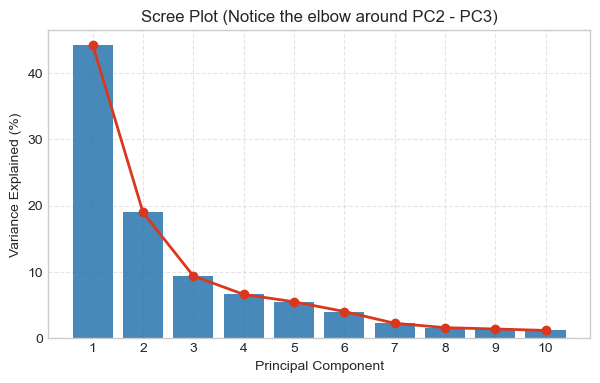

In [5]:
# Plot the Scree Plot
plt.figure(figsize=(7, 4))
plt.bar(range(1, 11), exp_var[:10] * 100, color='#1b6ca8', alpha=0.8)
plt.plot(range(1, 11), exp_var[:10] * 100, color='#d9381e', marker='o', lw=2)

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot (Notice the elbow around PC2 - PC3)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 1.3 Non-Linear Dimensionality Reduction: t-SNE

Comparing linear and non-linear approaches:
* **PCA (Linear):** Projects straight lines from a global viewpoint. It preserves the overall spread of data.
* **t-SNE (Non-Linear):** Preserves local neighbor relationships. It creates separated "islands" of similar samples.

*Rule:* t-SNE is **only for visualization**. Never use t-SNE coordinates as inputs for training other machine learning models!

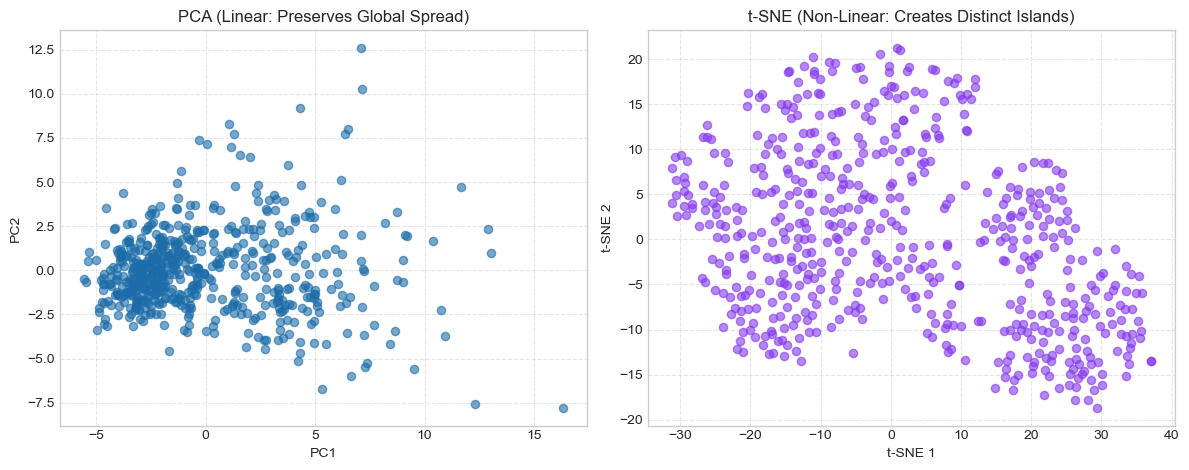

In [6]:
# Run t-SNE (unrolling the data into 2 dimensions)
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)

# Side-by-side comparison: PCA vs. t-SNE
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# PCA plot
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], color='#1b6ca8', alpha=0.6, s=35)
axes[0].set_title('PCA (Linear: Preserves Global Spread)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, linestyle='--', alpha=0.5)

# t-SNE plot
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], color='#8338ec', alpha=0.6, s=35)
axes[1].set_title('t-SNE (Non-Linear: Creates Distinct Islands)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Part 2: Clustering

Clustering groups similar samples together without using any predefined labels.

We will look at two popular methods:
1. **K-Means Clustering:** Groups samples around $K$ central points (centroids).
2. **Hierarchical Clustering:** Builds a tree of relationships (dendrogram) from bottom to top.

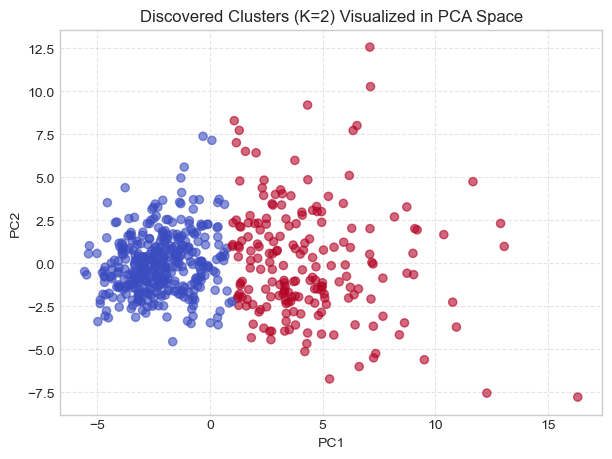

Cluster 0: 375 patients
Cluster 1: 194 patients


In [7]:
# Fit K-Means with the optimal K = 2
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Plot the 2 clusters on our 2D PCA map
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.6, s=35)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Discovered Clusters (K=2) Visualized in PCA Space')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Cluster 0: {sum(cluster_labels == 0)} patients")
print(f"Cluster 1: {sum(cluster_labels == 1)} patients")

### 2.2 Hierarchical Clustering & Dendrograms

Hierarchical clustering builds a tree from the bottom up:
1. Every patient starts as their own cluster.
2. The two most similar patients are joined together.
3. This repeats step-by-step until all patients join into a single tree called a **Dendrogram**.

Cutting the tree horizontally with a line reveals our clusters!

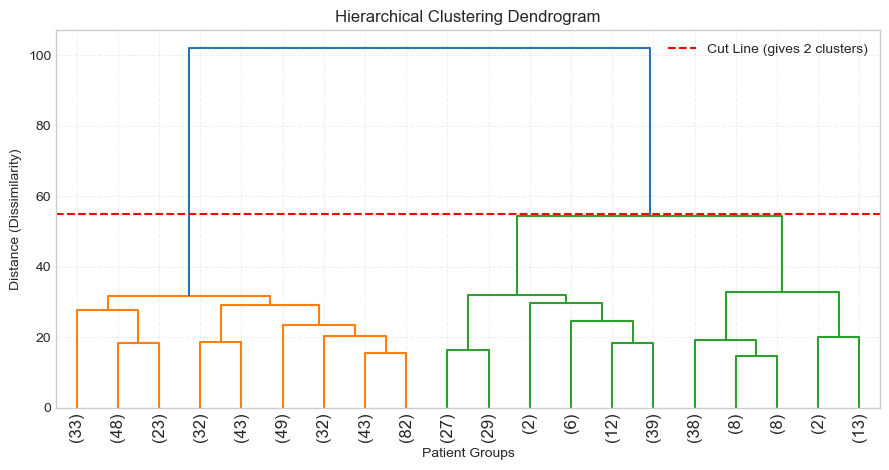

In [8]:
# Compute hierarchical clustering using Ward linkage
linkage_matrix = linkage(X_scaled, method='ward')

# Plot the Dendrogram (showing the top 20 merges)
plt.figure(figsize=(9, 4.8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.axhline(y=55, color='red', linestyle='--', label='Cut Line (gives 2 clusters)')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Patient Groups')
plt.ylabel('Distance (Dissimilarity)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Clustermap: Grouping Genes and Patients Together

In biology, we often want to cluster both **patients** (rows) and **genes** (columns) at the same time.

A **Clustermap** shows:
* **Row tree:** Groups patients with similar overall expression.
* **Column tree:** Groups genes that turn on and off together (co-regulated pathways).

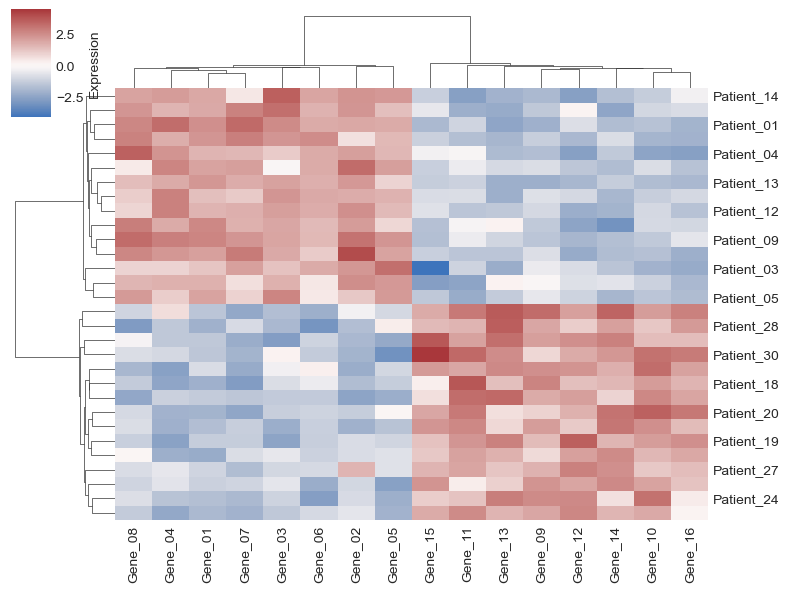

In [9]:
# Create a small simulated gene expression panel (30 patients x 16 genes)
np.random.seed(RANDOM_STATE)

# Module 1 (Genes 1-8): Active in Patients 1-15
mod1 = np.random.normal(loc=2.0, scale=0.8, size=(15, 8))
mod1_rest = np.random.normal(loc=-1.5, scale=0.8, size=(15, 8))
block1 = np.vstack([mod1, mod1_rest])

# Module 2 (Genes 9-16): Active in Patients 16-30
mod2 = np.random.normal(loc=-1.5, scale=0.8, size=(15, 8))
mod2_rest = np.random.normal(loc=2.0, scale=0.8, size=(15, 8))
block2 = np.vstack([mod2, mod2_rest])

expr_matrix = np.hstack([block1, block2])
expr_df = pd.DataFrame(expr_matrix,
                       index=[f"Patient_{i+1:02d}" for i in range(30)],
                       columns=[f"Gene_{j+1:02d}" for j in range(16)])

# Render the Clustermap
sns.clustermap(expr_df, cmap='vlag', center=0, figsize=(8, 6),
               dendrogram_ratio=(0.15, 0.15), cbar_kws={'label': 'Expression'})
plt.show()

---
## Part 3: The Standard Bioinformatic Workflow (PCA + Clustering)

In real bioinformatics projects (like RNA-seq), we rarely cluster raw high-dimensional data directly.

Instead, we follow this standard 3-step workflow:
1. **Standardize:** Make sure all features are on the same scale (`StandardScaler`).
2. **Reduce Dimensions with PCA:** Keep the top components to remove random noise and compress the data.
3. **Cluster in PCA Space:** Run K-Means on the PCA components instead of the raw 30 features.

In [10]:
# Step 1: Standardize
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw)

# Step 2: PCA (keep top 5 components)
pca_5 = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca_5 = pca_5.fit_transform(X_norm)

# Step 3: K-Means on the 5 PCA components
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_pca_5)


print("\nClustering in PCA space gives cleaner, tighter clusters because noise was removed!")


Clustering in PCA space gives cleaner, tighter clusters because noise was removed!
